# About this notebook

In this notebook I am analyzing the database to derive insights, which are going  to be used in feature engineering and selection, and the parts that come afterward.

 Through these insights I will decide which models are best for this project and also decide how they should work.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import yaml

# Loading dataset

In [2]:
dataset_dir = '../dataset'
files = os.listdir(dataset_dir)
dataset_files = []

for file in files:
    if '.csv' in file:
        dataset_files.append(file)

df = pd.DataFrame()

for file in dataset_files:
    temp_df = pd.read_csv(Path(dataset_dir, file))

    df = pd.concat([df, temp_df])

df.info()
print(df.head())

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max                 int64  
 

# Checking for class imbalance

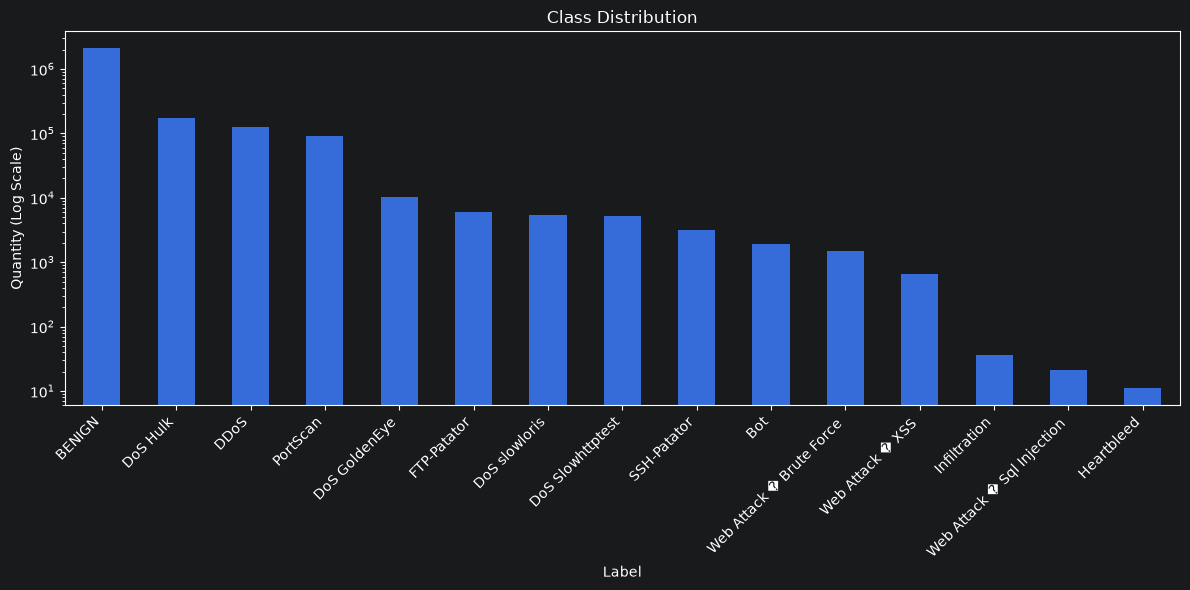

In [3]:
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

label_counts = df['Label'].value_counts()

plt.figure(figsize = (12, 6))
label_counts.plot(kind = 'bar')

plt.yscale('log')

plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.ylabel("Quantity (Log Scale)")
plt.tight_layout()

plt.show()

Looking at the barchart, there is heavy class imbalance. I think I should **implement SMOTE** to handle this.

# Data validation

In [4]:
pd.set_option("display.float_format", "{:.2f}".format)
df.max(numeric_only=True)

Destination Port                  65535.00
Flow Duration                 119999998.00
Total Fwd Packets                219759.00
Total Backward Packets           291922.00
Total Length of Fwd Packets    12900000.00
                                  ...     
Active Min                    110000000.00
Idle Mean                     120000000.00
Idle Std                       76900000.00
Idle Max                      120000000.00
Idle Min                      120000000.00
Length: 78, dtype: float64

Looking at the above table, the best datatype for storing these **values is float32 and int32**, will **need to remove the np.inf** values.

In [5]:
df.min(numeric_only=True)

Destination Port                0.00
Flow Duration                 -13.00
Total Fwd Packets               1.00
Total Backward Packets          0.00
Total Length of Fwd Packets     0.00
                               ...  
Active Min                      0.00
Idle Mean                       0.00
Idle Std                        0.00
Idle Max                        0.00
Idle Min                        0.00
Length: 78, dtype: float64

In the above minimum values, it can be seen that some columns which are negative cannot be valid:

1. Flow duration: cannot be negative as it is time.
2. Flow bytes/s: Bytes transferred cannot be negative.
3. Flow packets/s: same reason as no.2
4. IAT statistics: Time difference cannot be negative if packets are ordered correctly.
5. Header Lengths: these are sum of bytes and cannot be negative.
6. Segment size: are length in bytes, cannot be negative.
7. Init_Win_bytes_forward and backward can be negative if the protocol is not TCP.

In [6]:
negative_counts = (df.select_dtypes(include="number") < 0).sum()
negative_counts[negative_counts > 0]

Flow Duration                  107
Flow Bytes/s                    78
Flow Packets/s                 107
Flow IAT Mean                  107
Flow IAT Max                   107
Flow IAT Min                  2881
Fwd IAT Min                     17
Fwd Header Length               35
Bwd Header Length               22
Fwd Header Length.1             35
Init_Win_bytes_forward      911027
Init_Win_bytes_backward    1216341
min_seg_size_forward            35
dtype: int64

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(col, df[df[col] < 0][col].unique())

From the output, it seems dataset has invalid values, integer overflows and other issues.
Upon checking on internet, I learned this dataset (CICIDS2017) is made using CICFlowMeter, bugs in it may have caused these issues, as in real world similar situations may repeat it'd be wiser to **make a validator.**

I should also **account for missing values, NaN and inf** in the validator.

For now though, I'll just drop the invalid values and proceed with EDA.